In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel

from torchvision import models
import torch.nn as nn

# ---------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "Salesforce/blip2-opt-2.7b"
LORA_CKPT = "ckpt/Phase2/Blip2DegradationCaption/best_finetuned_model"
CLASSIFIER_CKPT = "ckpt/Phase1/DegradationClassifier/best_degradation_classifier_model.pth"

# ---------------------------------------------------------
# 1. LOAD BLIP-2 + LoRA
# ---------------------------------------------------------
print("Loading BLIP-2 processor...")
processor = Blip2Processor.from_pretrained(MODEL_NAME)
processor.tokenizer.pad_token = processor.tokenizer.eos_token

print("Loading BLIP-2 base model (8-bit)...")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

base_model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, LORA_CKPT)
model.eval()

# ---------------------------------------------------------
# 2. LOAD DEGRADATION CLASSIFIER
# ---------------------------------------------------------

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # -------- ResNet18 backbone --------
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.model = models.resnet18(weights=weights)

        # -------- Replace classifier head --------
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

ckpt = torch.load(CLASSIFIER_CKPT, map_location=device)

LABEL_MAP = ckpt["label_map"]
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(LABEL_MAP)

classifier = SimpleCNN(num_classes=NUM_CLASSES).to(device)
classifier.load_state_dict(ckpt["model_state_dict"])
classifier.eval()

print("✓ Classifier loaded")

# ---------------------------------------------------------
# 3. TRANSFORM FOR CLASSIFIER
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

severity_map = {
    "1": "light",
    "2": "moderate",
    "3": "heavy"
}

# ---------------------------------------------------------
# 4. BLIP GENERATION FUNCTION
# ---------------------------------------------------------
@torch.inference_mode()
def generate_captions(image, model, processor, device):
    prompt = "Question: Describe this scene. Answer:"

    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(device)

    gen_kwargs = {
        "max_new_tokens": 60,
        "num_beams": 3,
        "repetition_penalty": 1.2,
        "no_repeat_ngram_size": 3,
        "length_penalty": 0.8,
        "eos_token_id": processor.tokenizer.eos_token_id,
        "pad_token_id": processor.tokenizer.pad_token_id
    }

    with model.disable_adapter():
        ori_generated_ids = model.generate(**inputs, **gen_kwargs)
        ori_caption = processor.batch_decode(ori_generated_ids, skip_special_tokens=True)[0]
        ori_caption = ori_caption.replace(prompt, "").strip()
        
    # Generate fine-tuned caption (adapter enabled)
    ft_generated_ids = model.generate(**inputs, **gen_kwargs)
    ft_caption = processor.batch_decode(ft_generated_ids, skip_special_tokens=True)[0]
    ft_caption = ft_caption.replace(prompt, "").strip()
    
    # Clean up the output to prevent hallucinated "Question: ... Answer: ..." loops
    # This splits the string at the first newline or "Question:" and takes just the first sentence
    ori_caption = ori_caption.split("Question:")[0].split("\n")[0].strip()
    ft_caption = ft_caption.split("Question:")[0].split("\n")[0].strip()
    return ori_caption, ft_caption

# ---------------------------------------------------------
# 5. CLASSIFIER ENHANCED CAPTION
# ---------------------------------------------------------
@torch.inference_mode()
def add_degradation_caption_from_base(image, classifier_model):

    # ---------------- BLIP BASE CAPTION ----------------
    prompt = "Question: Describe this scene. Answer:"

    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(device)

    with model.disable_adapter():  # ✔ IMPORTANT FIX
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            num_beams=4
        )

    caption = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].replace(prompt, "").strip()

    # ---------------- CLASSIFIER ----------------
    img_tensor = transform(image).unsqueeze(0).to(device)

    logits = classifier_model(img_tensor)
    pred_idx = logits.argmax(dim=1).item()

    raw_label = IDX_TO_LABEL[pred_idx]
    deg_type, sev_num = raw_label.split("_")

    degradation_text = f"{severity_map[sev_num]} {deg_type.lower()}"

    caption = caption.rstrip(" .,!?:;")
    caption = f"{caption} in {degradation_text} conditions"

    return caption, degradation_text


# ---------------------------------------------------------
# 6. FULL PIPELINE
# ---------------------------------------------------------
def full_pipeline(img_path):
    image = Image.open(img_path).convert("RGB")

    ori_cap, ft_cap = generate_captions(image, model, processor, device)
    enhanced_base_cap, deg_text = add_degradation_caption_from_base(image, classifier)

    return image, ori_cap, ft_cap, enhanced_base_cap, deg_text





In [43]:
def visualize(img_path):
    image, ori_cap, ft_cap, enhanced_cap, deg_text = full_pipeline(img_path)

    fig = plt.figure(figsize=(13, 6), facecolor="white")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1], wspace=0.06)

    # ---------------- IMAGE ----------------
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(image)
    ax_img.axis("off")

    for spine in ax_img.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("black")

    # ---------------- TEXT ----------------
    ax_text = fig.add_subplot(gs[1])
    ax_text.set_xlim(0, 1)
    ax_text.set_ylim(0, 1)
    ax_text.axis("off")

    # vertical separator
    ax_text.plot([0, 0], [0, 1], color="black", linewidth=1.2)

    # =================================================
    # 1. ORIGINAL BLIP-2 (TOP)
    # =================================================
    ax_text.text(
        0.05, 0.90,
        "Original BLIP-2",
        fontsize=14,
        fontweight="bold",
        color="#0b2f6b"
    )

    ax_text.plot([0.05, 0.95], [0.86, 0.86], color="#0b2f6b", linewidth=2)

    ax_text.text(
        0.05, 0.80,
        ori_cap,
        fontsize=12,
        wrap=True,
        va="top"
    )

    # =================================================
    # 2. ENHANCED (MIDDLE)
    # =================================================
    ax_text.text(
        0.05, 0.56,
        "Enhanced (Degradation-aware)",
        fontsize=14,
        fontweight="bold",
        color="#0b2f6b"
    )
    ax_text.plot([0.05, 0.95], [0.50, 0.50], color="#0b2f6b", linewidth=2)

    ax_text.text(
        0.05, 0.48,
        enhanced_cap,
        fontsize=12,
        wrap=True,
        va="top"
    )

    ax_text.text(
        0.05, 0.35,
        f"Detected: {deg_text}",
        fontsize=12,
        style="italic",
        color="gray"
    )

    # =================================================
    # 3. FINE-TUNED BLIP-2 (LAST)
    # =================================================

    ax_text.text(
        0.05, 0.24,
        "Fine-tuned BLIP-2",
        fontsize=14,
        fontweight="bold",
        color="#0b2f6b"
    )

    ax_text.plot([0.05, 0.95], [0.20, 0.20],
                 color="#0b2f6b", linewidth=2)

    ax_text.text(
        0.05, 0.14,
        ft_cap,
        fontsize=12,
        wrap=True,
        va="top"
    )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


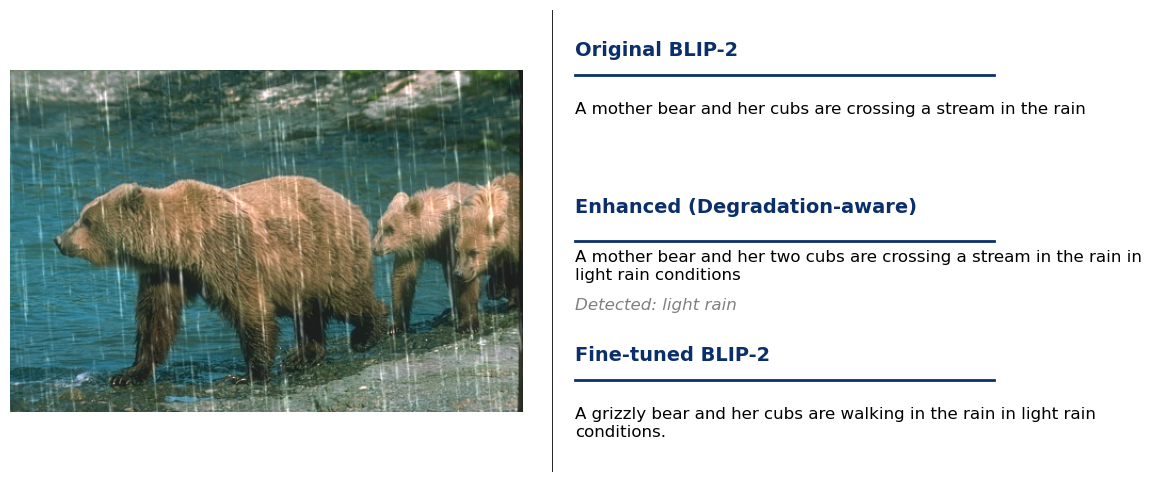

In [44]:
img_path = "datasets/deraining_datasets/Rain100L/rainy/rain-001.png"
visualize(img_path)

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


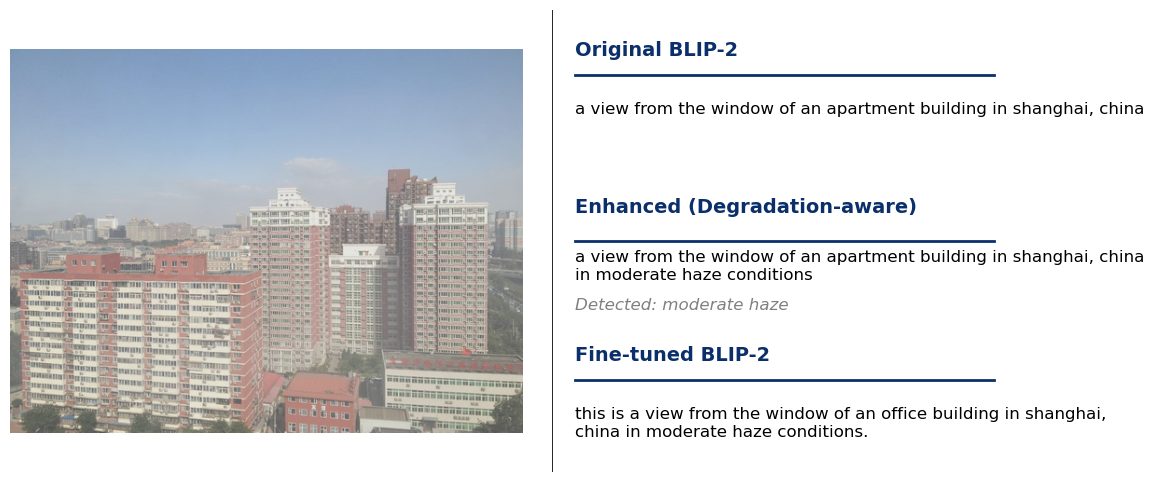

In [45]:
img_path = "datasets/dehazing_datasets/SOTS_outdoors/hazy/0001_0.8_0.2.jpg"
visualize(img_path)

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


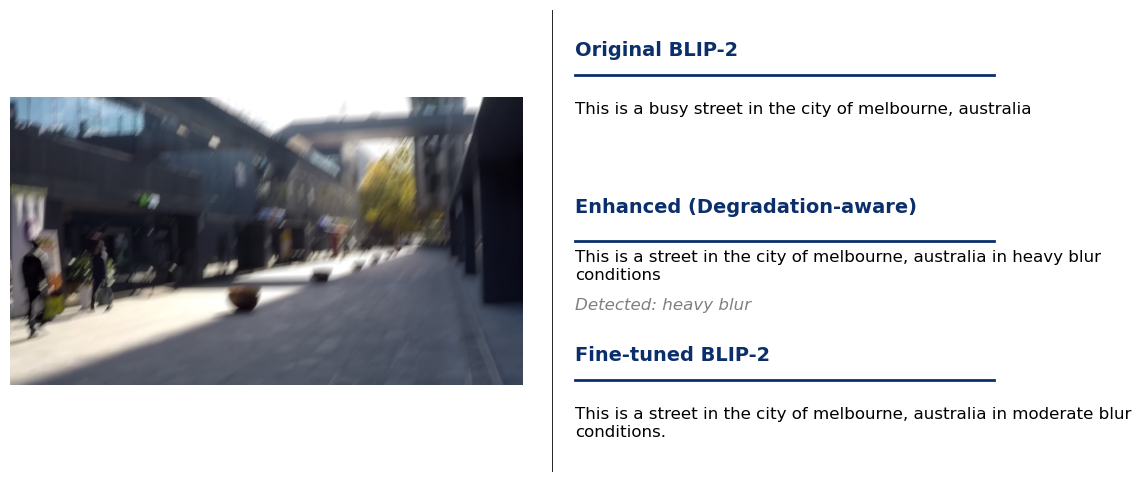

In [46]:
img_path = "datasets/deblurring_datasets/GoPro/test/blur/59.png"
visualize(img_path)

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


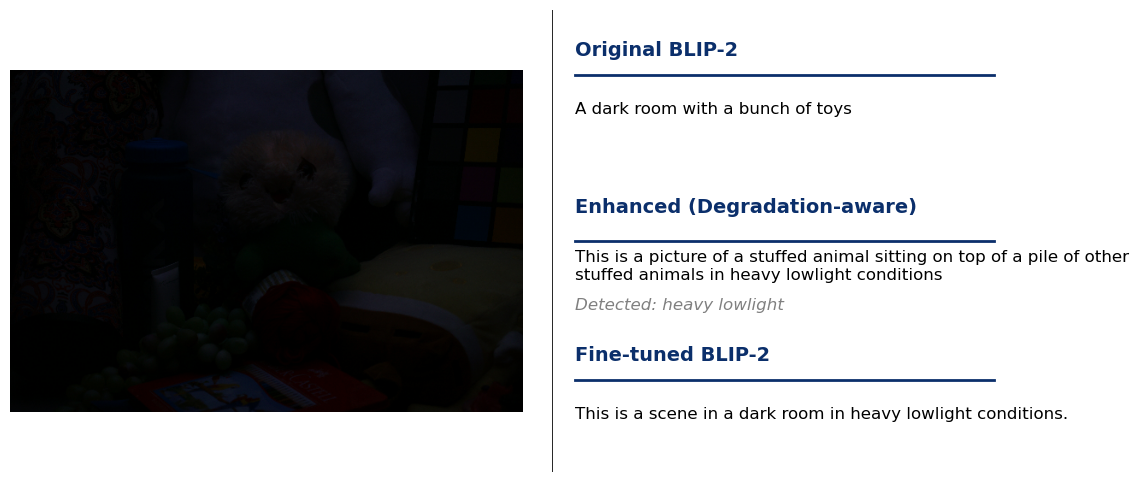

In [47]:
img_path = "datasets/delowlight_datasets/LoL/eval15/low/493.png"
visualize(img_path)

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


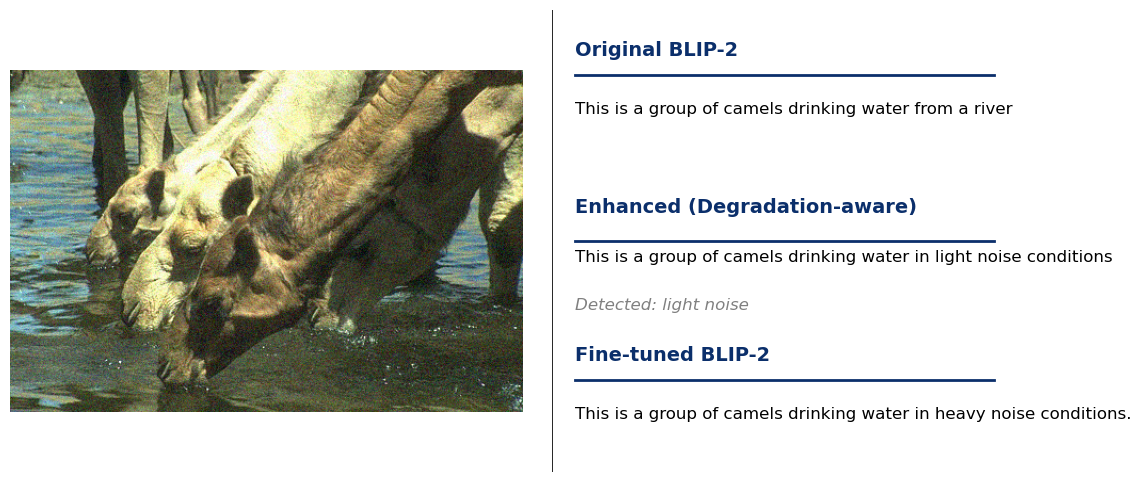

In [49]:
img_path = "datasets/denoising_datasets/CBSD68/noisy15/16077.png"
visualize(img_path)

/home/mmuuser/anaconda3/envs/vlunet/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


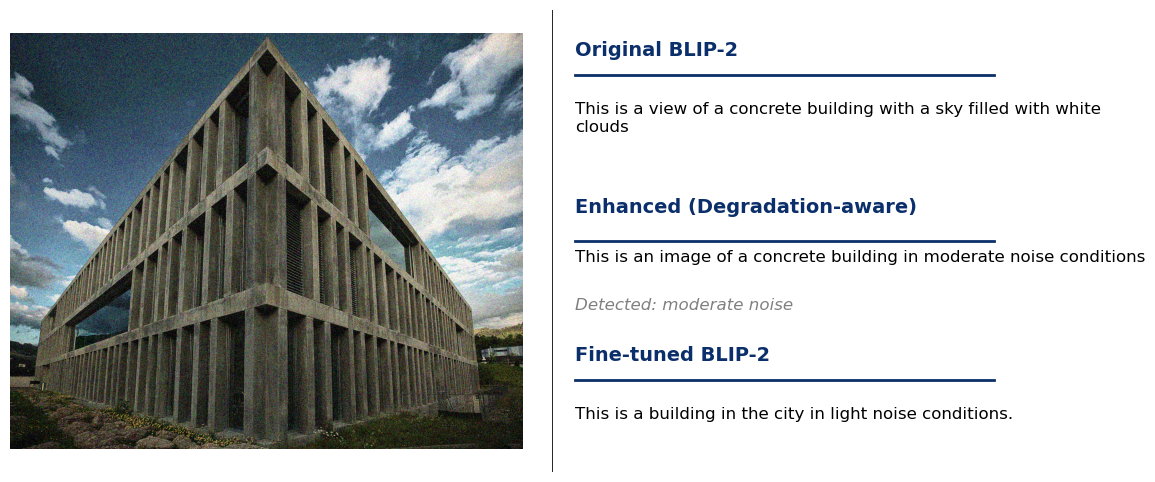

In [48]:
img_path = "datasets/denoising_datasets/Urban100_HR/noisy25/img_027.png"
visualize(img_path)

/tmp/ipykernel_284219/3804066406.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


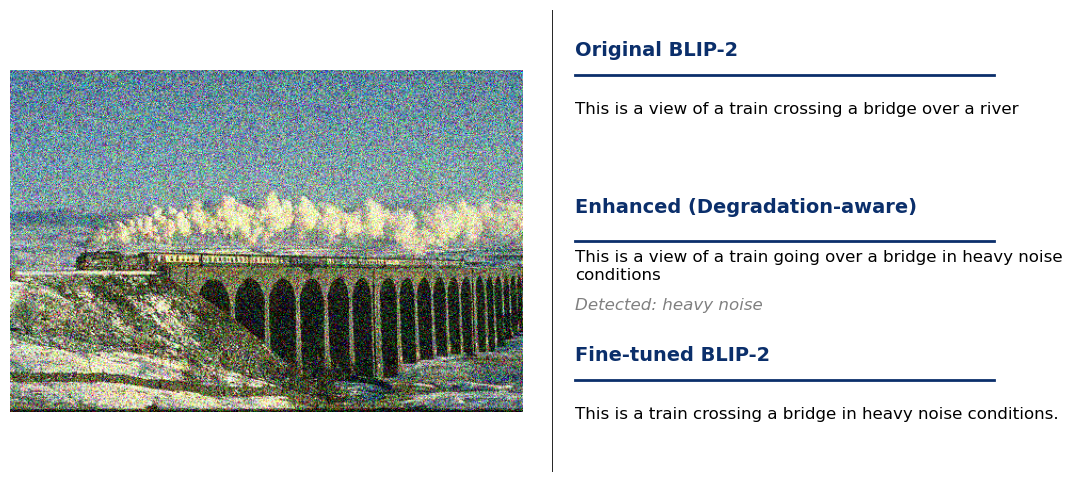

In [50]:
img_path = "datasets/denoising_datasets/CBSD68/noisy50/182053.png"
visualize(img_path)